In [2]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# --- DATA PREPROCESSING ---
file_path = 'Project Assignment/IEG part 1 code a+b/time_series_60min_singleindex.csv'

countries = ["CZ", "DE", "AT", "PL"]

target_columns = ["utc_timestamp"]
for c in countries:
    target_columns += [
        f"{c}_load_actual_entsoe_transparency",
        f"{c}_solar_generation_actual",
        f"{c}_wind_onshore_generation_actual"
    ]

df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

df_2019 = df.loc['2019-01-01':'2019-12-31'].copy().ffill().bfill()

# --- TECH DATA ---
def annuity(n, r):
    if r > 0:        
        return r / (1 - 1/(1+r)**n)
    else:
        return 1 / n

discount_rate = 0.07

tech_data = {
    'solar':       {'inv': 425000,  'fom': 0.03, 'life': 25, 'color': "#f1c40f"},
    'wind':        {'inv': 1182000, 'fom': 0.03, 'life': 25, 'color': "#3498db"},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'eff': 0.39, 'co2': 0.19, 'color': "#e67e22"},
    'nuclear':     {'ann_cap': 6000000, 'marg': 11.5, 'avail': 0.9, 'color': "#e74c3c"},
    'coal':        {'ann_cap': 1500000, 'marg': 55.0, 'avail': 1.0, 'co2': 0.34, 'color': "#7f8c8d"},
}

fuel_cost_gas = 21.6
vom_gas = 3.0

# Installed capacities for CF scaling
installed = {
    "CZ": {"solar": 2049, "wind": 316},
    "DE": {"solar": 45435, "wind": 52946},
    "PL": {"solar": 430, "wind": 5808},
    "AT": {"solar": 1193, "wind": 3035},
}

# Capacity factors
for c in countries:
    df_2019[f"{c}_solar_cf"] = (
        df_2019[f"{c}_solar_generation_actual"] / installed[c]["solar"]
    ).clip(0, 1)

    df_2019[f"{c}_wind_cf"] = (
        df_2019[f"{c}_wind_onshore_generation_actual"] / installed[c]["wind"]
    ).clip(0, 1)

# --- NETWORK ---
n = pypsa.Network()
n.set_snapshots(df_2019.index)

# Buses
n.add("Bus", countries)

# Carriers
for tech, d in tech_data.items():
    n.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

# --- LOADS ---
for c in countries:
    n.add("Load", f"{c}_load",
          bus=c,
          p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        name = f"{c}_{tech}"

        # Costs
        if tech in ["solar", "wind", "gas"]:
            capital_cost = annuity(d["life"], discount_rate) * d["inv"] * (1 + d["fom"])
        else:
            capital_cost = d["ann_cap"]

        # Marginal cost + CF
        if tech == "gas":
            marginal_cost = (fuel_cost_gas / d["eff"]) + vom_gas
            p_max_pu = 1.0
            efficiency = d["eff"]

        elif tech == "wind":
            marginal_cost = 0.01
            p_max_pu = df_2019[f"{c}_wind_cf"]
            efficiency = 1.0

        elif tech == "solar":
            marginal_cost = 0.01
            p_max_pu = df_2019[f"{c}_solar_cf"]
            efficiency = 1.0

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]
            efficiency = 1.0

        n.add("Generator",
              name,
              bus=c,
              carrier=tech,
              p_nom_extendable=True,
              capital_cost=capital_cost,
              marginal_cost=marginal_cost,
              efficiency=efficiency,
              p_max_pu=p_max_pu)

# --- TRANSMISSION ---
lines = [
    ("CZ", "DE", 3660),
    ("CZ", "AT", 2130),
    ("CZ", "PL", 1780),
    ("DE", "PL", 2260),
]

for b0, b1, cap in lines:
    n.add("Line", f"{b0}-{b1}", bus0=b0, bus1=b1, x=1, s_nom=cap)

# --- CO2 CONSTRAINT ---
n.add("GlobalConstraint", "co2_limit",
      type="primary_energy",
      carrier_attribute="co2_emissions",
      sense="<=",
      constant=10e6)

# --- 8. OPTIMIZATION ---
n.optimize(solver_name="highs")

# --- 9. RESULTS ---
# print(f"\nTotal System Cost: {n.objective/1e6:.2f} M€")

# print("\nCapacities:")
# print(n.generators.p_nom_opt)

# # --- 10. METRICS ---
# print("\n--- SYSTEM METRICS ---")

# total_demand = n.loads_t.p_set.sum().sum()
# total_gen = n.generators_t.p.sum().sum()

# print(f"Total Demand: {total_demand/1e6:.2f} TWh")
# print(f"Total Generation: {total_gen/1e6:.2f} TWh")

# # CO2
# co2 = 0
# for g in n.generators.index:
#     carrier = n.generators.at[g, "carrier"]
#     co2_int = n.carriers.at[carrier, "co2_emissions"]
#     eff = n.generators.at[g, "efficiency"]
#     gen = n.generators_t.p[g].sum()
#     co2 += gen * co2_int / eff

# print(f"CO2 Emissions: {co2/1e6:.2f} Mt")

# # Renewable share
# renewables = ["solar", "wind"]
# ren_gen = sum(
#     n.generators_t.p[g].sum()
#     for g in n.generators.index
#     if n.generators.at[g, "carrier"] in renewables
# )

# print(f"Renewable Share: {ren_gen/total_gen:.2%}")

# # LCOE
# print(f"System LCOE: {n.objective/total_demand:.2f} EUR/MWh")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_22056\3476084594.py:136: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL'], dtype='str', name='name')
DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2019-12-31 14:00:00', '2019-12-31 15:00:00',
               '2019-12-31 16:00:00', '2019-12-31 17:00:00',
               '2019-12-31 18:00:00', '2019-12-31 19:00:00',
               '2019-12-31 20:00:00', '2019-12-31 21:00:00',
               '201

('ok', 'optimal')

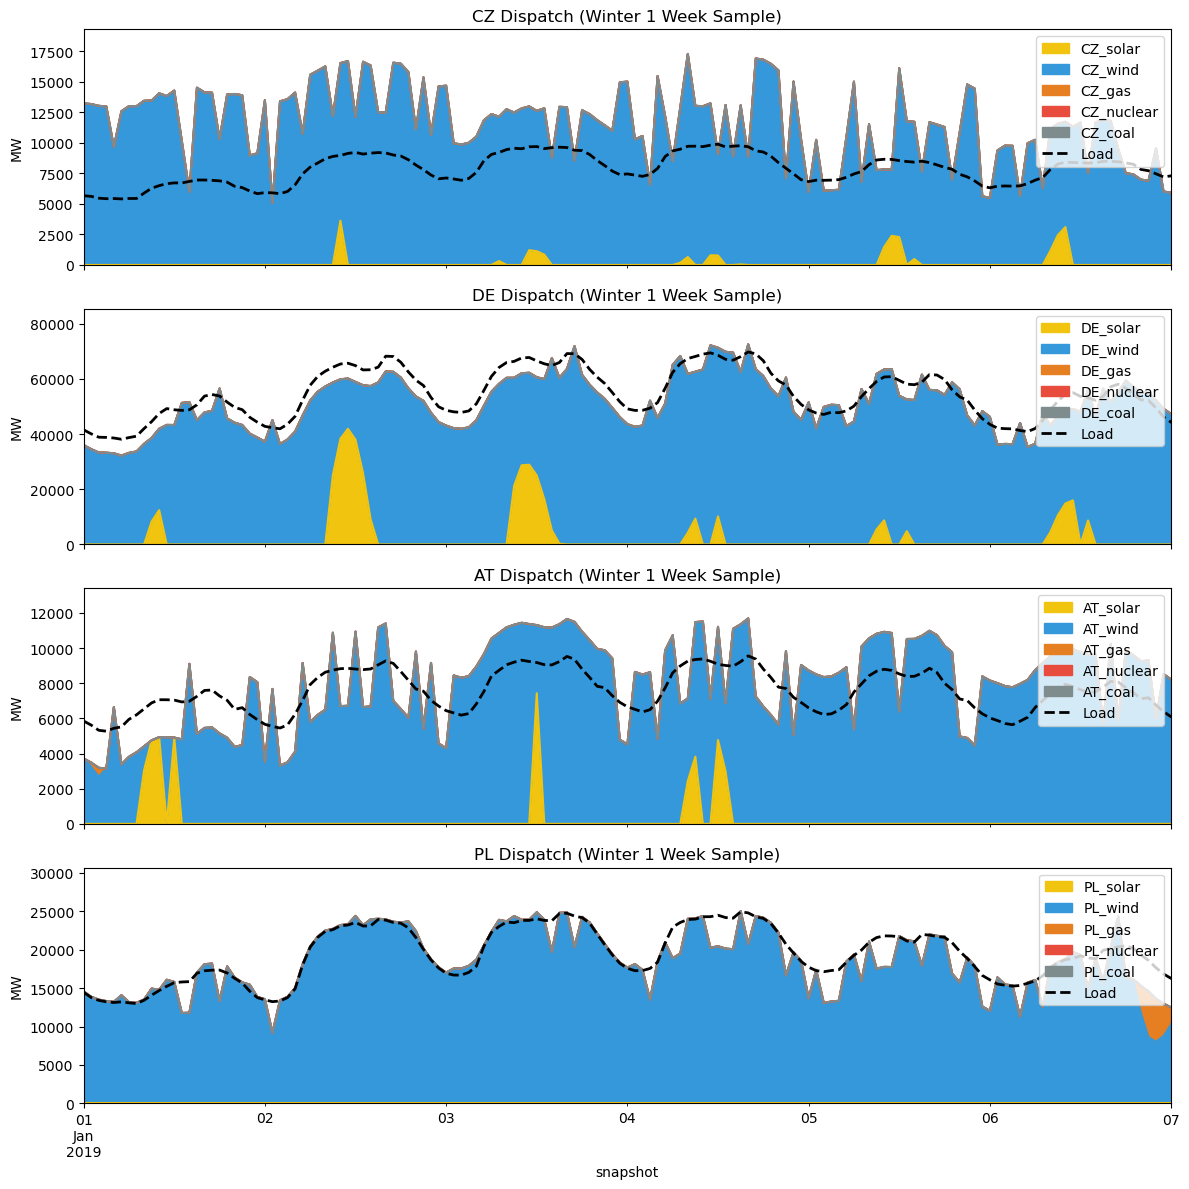

In [4]:
# --- DISPATCH PLOT (WINTER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    gens = [g for g in n.generators.index if g.startswith(c)]

    ax = axes[i] if len(countries) > 1 else axes

    # Generation stack
    n.generators_t.p[gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in gens]
    )

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

# Shared x-axis (time window)
plt.xlim("2019-01-01", "2019-01-07")

plt.tight_layout()
plt.show()

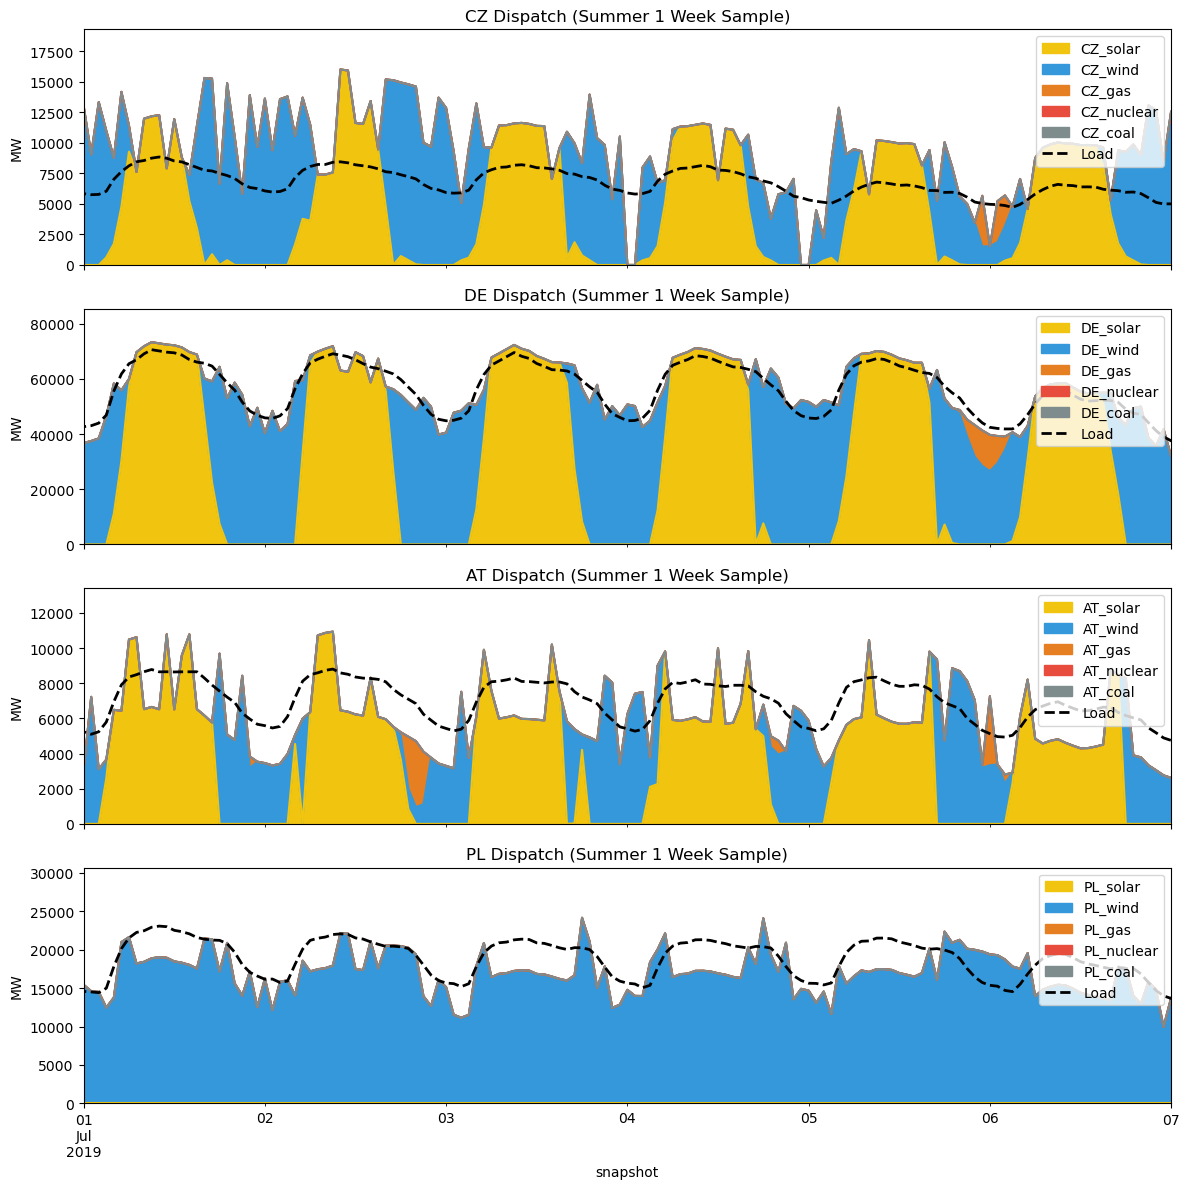

In [5]:
# --- DISPATCH PLOT (SUMMER) ---

fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    gens = [g for g in n.generators.index if g.startswith(c)]

    ax = axes[i] if len(countries) > 1 else axes

    # Generation stack
    n.generators_t.p[gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in gens]
    )

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Summer 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

# Shared x-axis (time window)
plt.xlim("2019-07-01", "2019-07-07")

plt.tight_layout()
plt.show()

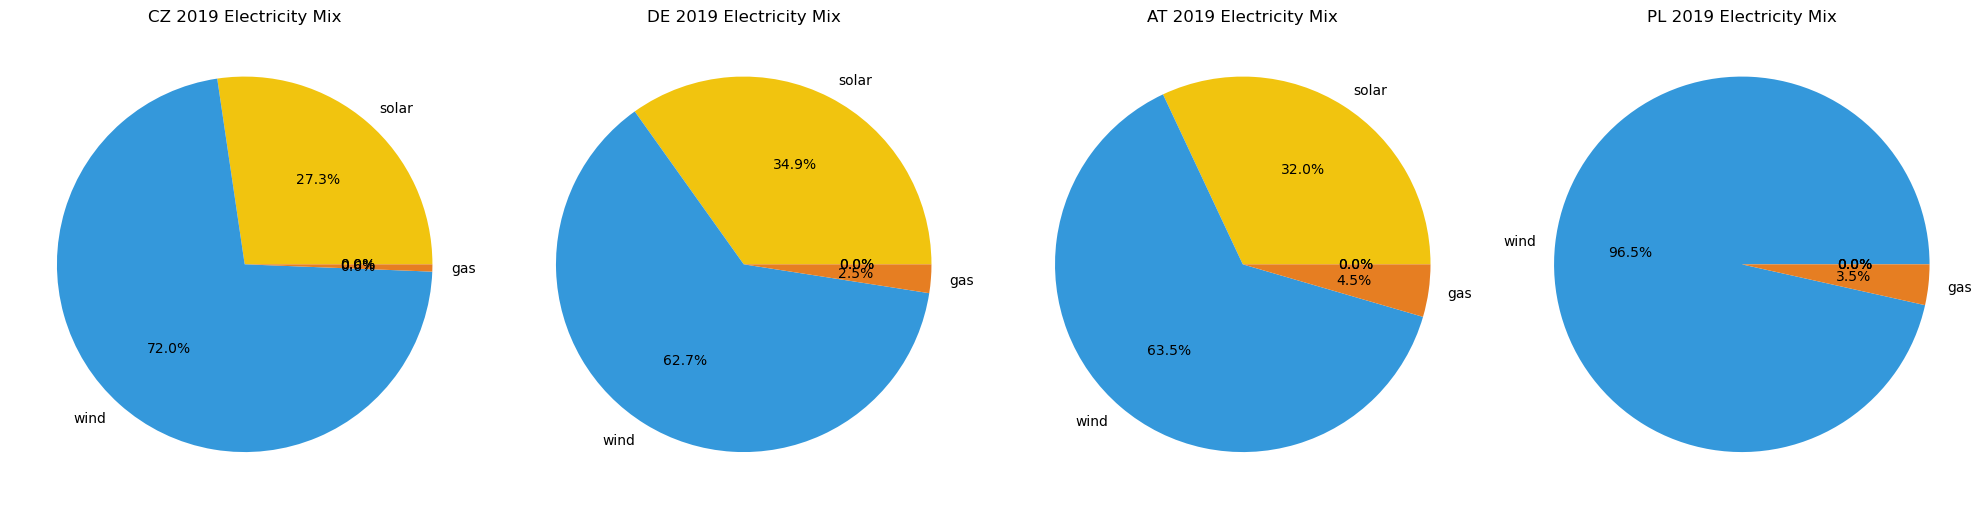

In [6]:
# --- ELECTRICITY MIX BY COUNTRY ---

fig, axes = plt.subplots(1, len(countries), figsize=(5*len(countries), 5))

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]

    gen_by_carrier = {}

    for g in gens:
        carrier = n.generators.at[g, "carrier"]
        energy = n.generators_t.p[g].sum()

        if carrier not in gen_by_carrier:
            gen_by_carrier[carrier] = 0

        gen_by_carrier[carrier] += energy

    # Convert to Series
    gen_by_carrier = pd.Series(gen_by_carrier)

    # Plot
    gen_by_carrier.plot(
        kind="pie",
        ax=ax,
        autopct="%1.1f%%",
        colors=[n.carriers.at[carr, "color"] for carr in gen_by_carrier.index]
    )

    ax.set_title(f"{c} 2019 Electricity Mix")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [7]:
gen_by_carrier

solar      0.000000e+00
wind       1.507438e+08
gas        5.450452e+06
nuclear    0.000000e+00
coal       0.000000e+00
dtype: float64

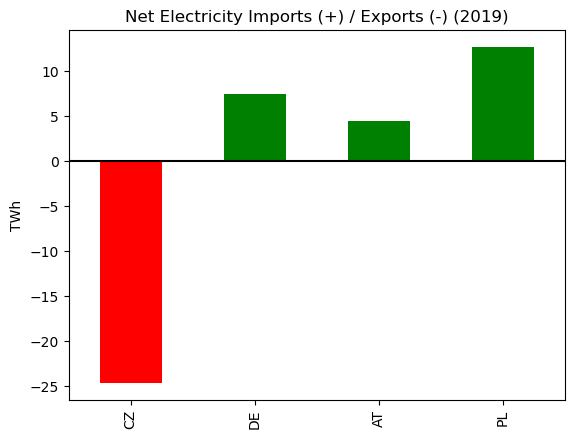


Net Imports (+) / Exports (-) [TWh]:
CZ   -24.626728
DE     7.441097
AT     4.462222
PL    12.723410
dtype: float64


In [8]:
net_imports = {c: 0 for c in countries}

for line in n.lines.index:
    bus0 = n.lines.at[line, "bus0"]
    bus1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    net_imports[bus0] -= flow.sum()
    net_imports[bus1] += flow.sum()

net_imports = pd.Series(net_imports) / 1e6  # TWh

net_imports.plot(
    kind="bar",
    color=["green" if v > 0 else "red" for v in net_imports]
)

plt.axhline(0, color='black')
plt.ylabel("TWh")
plt.title("Net Electricity Imports (+) / Exports (-) (2019)")
plt.show()

print("\nNet Imports (+) / Exports (-) [TWh]:")
print(net_imports)

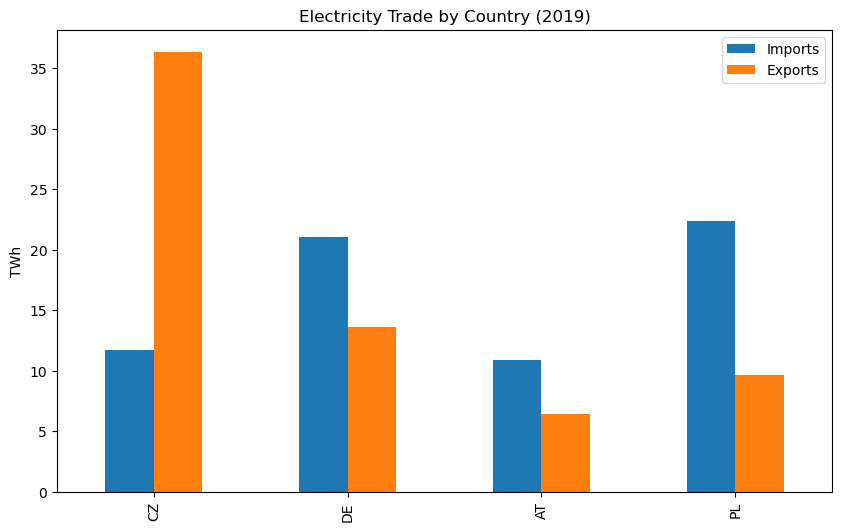

In [9]:
imports = {c: 0 for c in countries}
exports = {c: 0 for c in countries}

for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    exports[b0] += flow.clip(lower=0).sum()
    imports[b1] += flow.clip(lower=0).sum()

    exports[b1] += (-flow.clip(upper=0)).sum()
    imports[b0] += (-flow.clip(upper=0)).sum()

imports = pd.Series(imports) / 1e6
exports = pd.Series(exports) / 1e6

df_trade = pd.DataFrame({
    "Imports": imports,
    "Exports": exports
})

df_trade.plot(kind="bar", figsize=(10,6))

plt.ylabel("TWh")
plt.title("Electricity Trade by Country (2019)")
plt.show()

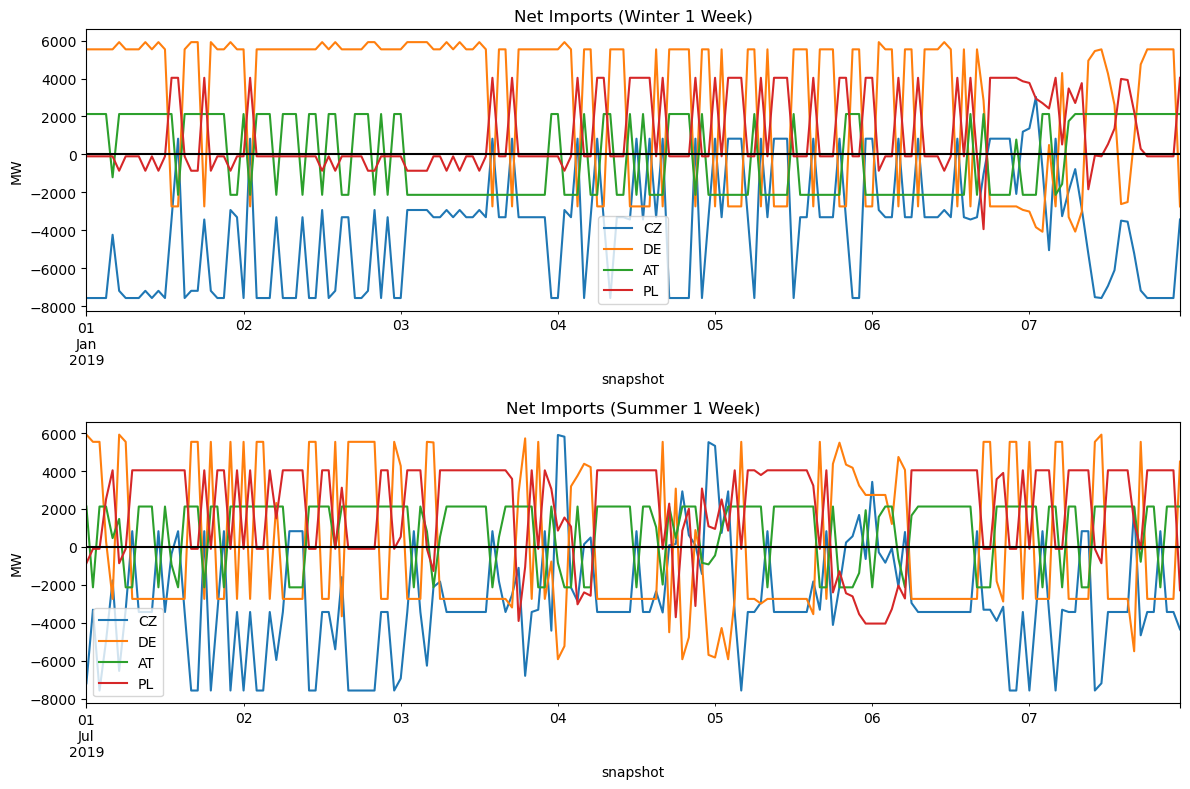

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

weeks = {
    "Winter 1 Week": ("2019-01-01", "2019-01-07"),
    "Summer 1 Week": ("2019-07-01", "2019-07-07"),
}

for ax, (title, (start, end)) in zip(axes, weeks.items()):
    
    for c in countries:
        net = 0
        for line in n.lines.index:
            b0 = n.lines.at[line, "bus0"]
            b1 = n.lines.at[line, "bus1"]
            flow = n.lines_t.p0[line]

            if c == b0:
                net -= flow
            elif c == b1:
                net += flow

        net.loc[start:end].plot(ax=ax, label=c)

    ax.axhline(0, color='black')
    ax.set_title(f"Net Imports ({title})")
    ax.set_ylabel("MW")
    ax.legend()

plt.tight_layout()
plt.show()